# TripletNet4: Strided Conv1D triplet encoder

This notebook trains the model with **5-fold anchor-group cross-validation** and then runs a thesis-oriented post-training analysis suite. The quantitative analysis prioritizes out-of-fold validation predictions; the latent-space and nearest-neighbour sections are used for interpretability and qualitative diagnosis.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from cv_training import (
    FoldTrainingConfig,
    TRIPLET_COLUMNS,
    make_artist_disjoint_kfold_splits,
    run_one_fold_margin,
    summarize_cv_results,
)
from dataset import filter_triplets, process_artists
from model import MODEL_REGISTRY
from utils import set_seed


In [2]:
SEED = 3407
set_seed(SEED)

MODEL_NAME = "TripletNet4"
MODEL_CLASS = MODEL_REGISTRY[MODEL_NAME]

BASE_DIR = Path("../data/video_embeddings")
TRIPLETS_CSV = Path("../data/triplets/triplets_ids_spot.csv")
OUTPUT_DIR = Path("checkpoints") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
NUM_EPOCHS = 30
N_FOLDS = 5
NUM_WORKERS = 0
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-6
EARLY_STOPPING_PATIENCE = 8
MARGINS = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
NEGATIVE_MINING = "memory_bank_semihard"
MINING_FALLBACK = "closest_valid"

print(f"Using device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"5-fold CV with {N_FOLDS} artist-disjoint folds")
print(f"negative_mining={NEGATIVE_MINING} | margin grid={MARGINS} | batch_size={BATCH_SIZE}")


Using device: cuda
Model: TripletNet4
5-fold CV with 5 artist-disjoint folds
negative_mining=memory_bank_semihard | margin grid=[0.1, 0.2, 0.3, 0.5, 0.7, 0.9] | batch_size=128


In [3]:
artist_averages = process_artists(BASE_DIR)
if not artist_averages:
    raise RuntimeError(f"No artist embeddings found under {BASE_DIR!s}. Check BASE_DIR.")

sample_embedding = next(iter(artist_averages.values()))
if sample_embedding.ndim != 2:
    raise ValueError(f"Expected artist embeddings shaped (seq_len, d_model), got {tuple(sample_embedding.shape)}")

SEQ_LEN = int(sample_embedding.shape[0])
D_MODEL = int(sample_embedding.shape[1])
MODEL_KWARGS = {"d_model": D_MODEL, "seq_len": SEQ_LEN}

raw_triplet_df = pd.read_csv(TRIPLETS_CSV)
filtered_triplet_df = filter_triplets(raw_triplet_df, artist_averages)
if filtered_triplet_df.empty:
    raise RuntimeError("No usable triplets after filtering. Check triplet CSV IDs and embedding folders.")

folds = make_artist_disjoint_kfold_splits(filtered_triplet_df, n_splits=N_FOLDS, seed=SEED)
fold_stats_df = pd.DataFrame([stats for _, _, _, stats in folds])

print(f"Artists with embeddings: {len(artist_averages)}")
print(f"Filtered triplets: {len(filtered_triplet_df)}")
print(f"Embedding shape: seq_len={SEQ_LEN}, d_model={D_MODEL}")
display(fold_stats_df)


Artists with embeddings: 3892
Filtered triplets: 15755
Embedding shape: seq_len=30, d_model=768


,fold,strategy,train_rows,val_rows,dropped_cross_partition_rows,kept_row_ratio,train_artists,val_artists,train_artist_partition_size,val_artist_partition_size,anchor_overlap,artist_overlap
0,1,artist_disjoint_kfold,8269,131,7355,0.533164,2397,256,2405,602,False,False
1,2,artist_disjoint_kfold,8037,120,7598,0.517740,2396,258,2405,602,False,False
2,3,artist_disjoint_kfold,8295,137,7323,0.535195,2397,267,2406,601,False,False
3,4,artist_disjoint_kfold,8034,129,7592,0.518121,2394,256,2406,601,False,False
4,5,artist_disjoint_kfold,7714,141,7900,0.498572,2393,278,2406,601,False,False


In [4]:
training_config = FoldTrainingConfig(
    model_name=MODEL_NAME,
    model_class=MODEL_CLASS,
    model_kwargs=MODEL_KWARGS,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    distance_fn="cosine",
    negative_mining=NEGATIVE_MINING,
    mining_fallback=MINING_FALLBACK,
    grad_clip=1.0,
)


def make_model():
    return MODEL_CLASS(**MODEL_KWARGS).to(DEVICE)


In [5]:
results = []

for margin in MARGINS:
    for fold_id, train_df, val_df, fold_stats in folds:
        print("=" * 100)
        print(
            f"Training {MODEL_NAME}: negative_mining={NEGATIVE_MINING}, "
            f"margin={margin:.2f}, fold={fold_id}/{N_FOLDS} | "
            f"train_rows={fold_stats['train_rows']} | val_rows={fold_stats['val_rows']}"
        )
        results.append(
            run_one_fold_margin(
                fold_id,
                train_df,
                val_df,
                margin,
                artist_averages,
                training_config,
                negative_source_df=filtered_triplet_df,
            )
        )

fold_summary_df, margin_summary_df = summarize_cv_results(results, OUTPUT_DIR, MODEL_NAME)

display(fold_summary_df)
display(margin_summary_df)


Training TripletNet4: negative_mining=memory_bank_semihard, margin=0.10, fold=1/5 | train_rows=8269 | val_rows=131
fold=1 | mining=memory_bank_semihard | margin=0.10 | epoch=001/30 | train_loss=0.05824 | train_acc=75.03% | val_loss=0.04099 | val_mrr=0.2533 | val_acc=93.89% | val_margin_acc=70.99% | lr=2.00e-04 | semi=80.7% | fallback=19.3% | skipped=0.0% | bank=2397
fold=1 | mining=memory_bank_semihard | margin=0.10 | epoch=002/30 | train_loss=0.06930 | train_acc=69.59% | val_loss=0.02587 | val_mrr=0.3400 | val_acc=94.66% | val_margin_acc=90.08% | lr=2.00e-04 | semi=99.4% | fallback=0.6% | skipped=0.0% | bank=2397
fold=1 | mining=memory_bank_semihard | margin=0.10 | epoch=003/30 | train_loss=0.04381 | train_acc=82.98% | val_loss=0.03204 | val_mrr=0.3309 | val_acc=96.95% | val_margin_acc=92.37% | lr=2.00e-04 | semi=100.0% | fallback=0.0% | skipped=0.0% | bank=2397
fold=1 | mining=memory_bank_semihard | margin=0.10 | epoch=004/30 | train_loss=0.05266 | train_acc=78.74% | val_loss=0.02817

,model,margin,negative_mining,fold,best_epoch,epochs_ran,best_val_mrr,best_val_acc,best_val_margin_acc,best_val_loss,mean_semi_hard_ratio,mean_fallback_ratio,mean_skipped_ratio,mean_memory_bank_size,checkpoint_path,history_path
0,TripletNet4,0.1,memory_bank_semihard,1,7,15,0.372431,0.977099,0.961832,0.027899,0.980836,0.019164,0.0,2397.0,checkpoints/TripletNet4/TripletNet4_margin_0.1...,checkpoints/TripletNet4/TripletNet4_margin_0.1...
1,TripletNet4,0.1,memory_bank_semihard,2,9,17,0.353737,0.908333,0.883333,0.040660,0.931032,0.068968,0.0,2396.0,checkpoints/TripletNet4/TripletNet4_margin_0.1...,checkpoints/TripletNet4/TripletNet4_margin_0.1...
2,TripletNet4,0.1,memory_bank_semihard,3,6,14,0.335827,0.919708,0.897810,0.041081,0.984543,0.015457,0.0,2397.0,checkpoints/TripletNet4/TripletNet4_margin_0.1...,checkpoints/TripletNet4/TripletNet4_margin_0.1...
3,TripletNet4,0.1,memory_bank_semihard,4,13,21,0.328221,0.891473,0.868217,0.065752,0.982633,0.017367,0.0,2394.0,checkpoints/TripletNet4/TripletNet4_margin_0.1...,checkpoints/TripletNet4/TripletNet4_margin_0.1...
4,TripletNet4,0.1,memory_bank_semihard,5,16,24,0.317251,0.907801,0.893617,0.026042,0.983358,0.016642,0.0,2393.0,checkpoints/TripletNet4/TripletNet4_margin_0.1...,checkpoints/TripletNet4/TripletNet4_margin_0.1...
5,TripletNet4,0.2,memory_bank_semihard,1,12,20,0.389898,0.946565,0.908397,0.037894,0.985409,0.014591,0.0,2397.0,checkpoints/TripletNet4/TripletNet4_margin_0.2...,checkpoints/TripletNet4/TripletNet4_margin_0.2...
6,TripletNet4,0.2,memory_bank_semihard,2,5,13,0.388946,0.933333,0.883333,0.054057,0.994315,0.005685,0.0,2396.0,checkpoints/TripletNet4/TripletNet4_margin_0.2...,checkpoints/TripletNet4/TripletNet4_margin_0.2...
7,TripletNet4,0.2,memory_bank_semihard,3,12,20,0.319803,0.890511,0.810219,0.069608,0.988107,0.011893,0.0,2397.0,checkpoints/TripletNet4/TripletNet4_margin_0.2...,checkpoints/TripletNet4/TripletNet4_margin_0.2...
8,TripletNet4,0.2,memory_bank_semihard,4,13,21,0.348331,0.945736,0.844961,0.066138,0.989058,0.010942,0.0,2394.0,checkpoints/TripletNet4/TripletNet4_margin_0.2...,checkpoints/TripletNet4/TripletNet4_margin_0.2...
9,TripletNet4,0.2,memory_bank_semihard,5,11,19,0.311891,0.921986,0.808511,0.061548,0.971289,0.028711,0.0,2393.0,checkpoints/TripletNet4/TripletNet4_margin_0.2...,checkpoints/TripletNet4/TripletNet4_margin_0.2...


,model,negative_mining,margin,mean_best_val_mrr,std_best_val_mrr,mean_best_val_acc,std_best_val_acc,mean_best_val_margin_acc,std_best_val_margin_acc,mean_best_val_loss,std_best_val_loss,mean_best_epoch,mean_epochs_ran,mean_semi_hard_ratio,mean_fallback_ratio,mean_skipped_ratio,mean_memory_bank_size
0,TripletNet4,memory_bank_semihard,0.2,0.351774,0.036946,0.927626,0.023068,0.851084,0.044285,0.057849,0.012582,10.6,18.6,0.985636,0.014364,0.0,2395.4
1,TripletNet4,memory_bank_semihard,0.1,0.341493,0.021812,0.920883,0.032997,0.900962,0.035889,0.040287,0.015856,10.2,18.2,0.972481,0.027519,0.0,2395.4
2,TripletNet4,memory_bank_semihard,0.3,0.335139,0.035408,0.916880,0.022854,0.792645,0.032161,0.087068,0.012687,8.6,16.6,0.995727,0.004273,0.0,2395.4
3,TripletNet4,memory_bank_semihard,0.5,0.315297,0.028688,0.915625,0.031434,0.637858,0.040490,0.171740,0.030494,10.0,18.0,0.998527,0.001473,0.0,2395.4
4,TripletNet4,memory_bank_semihard,0.7,0.295497,0.033002,0.920584,0.028501,0.520052,0.049370,0.269201,0.050413,6.8,14.8,0.998186,0.001814,0.0,2395.4
5,TripletNet4,memory_bank_semihard,0.9,0.287886,0.031751,0.894961,0.029893,0.366241,0.020584,0.414327,0.035427,12.0,20.0,0.998096,0.001904,0.0,2395.4



## Post-training analysis plan

After the 5-fold training finishes, this notebook reports the model from three complementary angles:

1. **Generalisation and stability**: compare margins across folds, inspect training/validation curves, and optionally compare all five model notebooks if their summary files exist.
2. **Triplet-learning quality**: aggregate out-of-fold validation predictions, then analyse positive vs negative cosine similarity, margin gaps, ranking accuracy, margin-satisfied accuracy, and threshold precision/recall/F1.
3. **Retrieval and latent-space usefulness**: use the selected best checkpoint to embed artists, compute nearest-neighbour retrieval metrics, inspect qualitative neighbours/errors, and visualise/diagnose the latent space using metadata when available.

The out-of-fold triplet analysis is the primary quantitative evidence because every prediction is made by a model that did not train on that fold's anchor artists. The latent-space plots and nearest-neighbour examples are interpretability checks, not the sole performance evidence.


In [6]:

import math
import warnings
from collections import defaultdict

import torch.nn.functional as F

ANALYSIS_DIR = OUTPUT_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Select the best margin by mean 5-fold validation MRR. Ties prefer higher ranking accuracy, then lower loss.
best_margin = float(margin_summary_df.iloc[0]["margin"])
best_margin_results = sorted(
    [item for item in results if float(item["margin"]) == best_margin],
    key=lambda item: int(item["fold"]),
)
best_fold_result = max(
    best_margin_results,
    key=lambda item: (item["best_val_mrr"], item["best_val_acc"], -item["best_val_loss"]),
)


def load_model_from_checkpoint(checkpoint_path: str | Path):
    checkpoint_path = Path(checkpoint_path)
    model = make_model()
    state = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model


def encode_triplet_distances(model, triplets, fold: int | None = None, margin: float | None = None) -> pd.DataFrame:
    rows = []
    model.eval()
    margin = best_margin if margin is None else float(margin)
    with torch.inference_mode():
        for idx, (anchor, positive, negative) in enumerate(triplets):
            anchor_input = anchor.unsqueeze(0).to(DEVICE).float()
            positive_input = positive.unsqueeze(0).to(DEVICE).float()
            negative_input = negative.unsqueeze(0).to(DEVICE).float()

            anchor_emb, positive_emb, negative_emb = model(anchor_input, positive_input, negative_input)
            positive_similarity = F.cosine_similarity(anchor_emb, positive_emb, dim=1).item()
            negative_similarity = F.cosine_similarity(anchor_emb, negative_emb, dim=1).item()
            positive_distance = 1.0 - positive_similarity
            negative_distance = 1.0 - negative_similarity
            margin_gap = negative_distance - positive_distance

            rows.append({
                "fold": fold,
                "triplet_id": idx,
                "positive_similarity": positive_similarity,
                "negative_similarity": negative_similarity,
                "positive_distance": positive_distance,
                "negative_distance": negative_distance,
                "similarity_gap": positive_similarity - negative_similarity,
                "margin_gap": margin_gap,
                "ranking_correct": positive_distance < negative_distance,
                "margin_satisfied": positive_distance + margin < negative_distance,
            })
    return pd.DataFrame(rows)


def build_oof_triplet_predictions() -> pd.DataFrame:
    frames = []
    for item in best_margin_results:
        fold_model = load_model_from_checkpoint(item["checkpoint_path"])
        fold_df = encode_triplet_distances(
            fold_model,
            item["val_triplets"],
            fold=int(item["fold"]),
            margin=float(item["margin"]),
        )
        fold_df["model"] = item["model"]
        fold_df["margin"] = float(item["margin"])
        fold_df["checkpoint_path"] = item["checkpoint_path"]
        frames.append(fold_df)
    if not frames:
        raise RuntimeError("No validation predictions were generated. Check results/best_margin_results.")
    return pd.concat(frames, ignore_index=True)


def pair_threshold_curve(oof_df: pd.DataFrame, thresholds: np.ndarray | None = None) -> pd.DataFrame:
    if thresholds is None:
        min_score = float(min(oof_df["positive_similarity"].min(), oof_df["negative_similarity"].min()))
        max_score = float(max(oof_df["positive_similarity"].max(), oof_df["negative_similarity"].max()))
        lower = max(-1.0, math.floor(min_score * 100) / 100)
        upper = min(1.0, math.ceil(max_score * 100) / 100)
        thresholds = np.linspace(lower, upper, 101)

    pos_scores = oof_df["positive_similarity"].to_numpy(dtype=float)
    neg_scores = oof_df["negative_similarity"].to_numpy(dtype=float)
    rows = []
    for threshold in thresholds:
        tp = int((pos_scores >= threshold).sum())
        fn = int((pos_scores < threshold).sum())
        fp = int((neg_scores >= threshold).sum())
        tn = int((neg_scores < threshold).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            "threshold": float(threshold),
            "precision": precision,
            "recall": recall,
            "specificity": specificity,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        })
    return pd.DataFrame(rows)


def safe_auc_metrics(oof_df: pd.DataFrame) -> dict[str, float]:
    y_true = np.concatenate([
        np.ones(len(oof_df), dtype=int),
        np.zeros(len(oof_df), dtype=int),
    ])
    y_score = np.concatenate([
        oof_df["positive_similarity"].to_numpy(dtype=float),
        oof_df["negative_similarity"].to_numpy(dtype=float),
    ])
    out = {"roc_auc": float("nan"), "average_precision": float("nan")}
    try:
        from sklearn.metrics import average_precision_score, roc_auc_score
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
        out["average_precision"] = float(average_precision_score(y_true, y_score))
    except Exception as exc:
        warnings.warn(f"sklearn metrics unavailable; ROC-AUC/AP skipped: {exc}")
    return out


oof_triplet_df = build_oof_triplet_predictions()
threshold_metrics_df = pair_threshold_curve(oof_triplet_df)
best_threshold_row = threshold_metrics_df.sort_values(["f1", "precision", "recall"], ascending=False).iloc[0]
auc_metrics = safe_auc_metrics(oof_triplet_df)

best_model = load_model_from_checkpoint(best_fold_result["checkpoint_path"])
best_checkpoint_path = Path(best_fold_result["checkpoint_path"])

print(f"Best margin by 5-fold mean validation MRR: {best_margin:.2f}")
print(f"Best single fold checkpoint for embedding-level analysis: fold={best_fold_result['fold']} -> {best_checkpoint_path}")
print(f"Out-of-fold validation triplets: {len(oof_triplet_df)}")
print(f"OOF ranking accuracy: {oof_triplet_df['ranking_correct'].mean():.2%}")
print(f"OOF margin-satisfied accuracy: {oof_triplet_df['margin_satisfied'].mean():.2%}")
print(f"Best threshold by F1: {best_threshold_row['threshold']:.3f}")
print(f"ROC-AUC: {auc_metrics['roc_auc']:.4f} | Average precision: {auc_metrics['average_precision']:.4f}")

display(oof_triplet_df.describe())
display(threshold_metrics_df.sort_values("f1", ascending=False).head(10))


Best margin by 5-fold mean validation MRR: 0.20
Best single fold checkpoint for embedding-level analysis: fold=1 -> checkpoints/TripletNet4/TripletNet4_margin_0.20_fold_1_best.pt
Out-of-fold validation triplets: 658
OOF ranking accuracy: 92.71%
OOF margin-satisfied accuracy: 84.95%
Best threshold by F1: 0.349
ROC-AUC: 0.9303 | Average precision: 0.9327


,fold,triplet_id,positive_similarity,negative_similarity,positive_distance,negative_distance,similarity_gap,margin_gap,margin
count,658.000000,658.000000,658.000000,658.000000,6.580000e+02,658.000000,658.000000,658.000000,6.580000e+02
mean,3.044073,65.496960,0.653268,0.007458,3.467322e-01,0.992542,0.645810,0.645810,2.000000e-01
std,1.425855,38.352933,0.250180,0.338322,2.501804e-01,0.338322,0.424287,0.424287,5.555338e-17
min,1.000000,0.000000,-0.290746,-0.759617,-1.192093e-07,0.102892,-0.712684,-0.712684,2.000000e-01
25%,2.000000,32.250000,0.519287,-0.254054,1.583276e-01,0.746102,0.372769,0.372769,2.000000e-01
50%,3.000000,65.000000,0.726671,-0.001609,2.733293e-01,1.001609,0.673663,0.673663,2.000000e-01
75%,4.000000,98.000000,0.841672,0.253898,4.807127e-01,1.254054,0.958549,0.958549,2.000000e-01
max,5.000000,140.000000,1.000000,0.897108,1.290746e+00,1.759617,1.636398,1.636398,2.000000e-01


,threshold,precision,recall,specificity,f1,tp,fp,fn,tn
63,0.3488,0.845376,0.889058,0.837386,0.866667,585,107,73,551
64,0.3664,0.851689,0.881459,0.846505,0.866318,580,101,78,557
65,0.3840,0.856928,0.864742,0.855623,0.860817,569,95,89,563
62,0.3312,0.831445,0.892097,0.819149,0.860704,587,119,71,539
66,0.4016,0.865116,0.848024,0.867781,0.856485,558,87,100,571
61,0.3136,0.819444,0.896657,0.802432,0.856313,590,130,68,528
67,0.4192,0.867717,0.837386,0.872340,0.852282,551,84,107,574
60,0.2960,0.808482,0.898176,0.787234,0.850972,591,140,67,518
58,0.2608,0.789542,0.917933,0.755319,0.848911,604,161,54,497
68,0.4368,0.874194,0.823708,0.881459,0.848200,542,78,116,580


### 1. Cross-validation stability and cross-model comparison


,model,negative_mining,margin,mean_best_val_mrr,std_best_val_mrr,mean_best_val_acc,std_best_val_acc,mean_best_val_margin_acc,std_best_val_margin_acc,mean_best_val_loss,std_best_val_loss,mean_best_epoch,mean_epochs_ran,mean_semi_hard_ratio,mean_fallback_ratio,mean_skipped_ratio,mean_memory_bank_size
0,TripletNet4,memory_bank_semihard,0.2,0.351774,0.036946,0.927626,0.023068,0.851084,0.044285,0.057849,0.012582,10.6,18.6,0.985636,0.014364,0.0,2395.4
1,TripletNet4,memory_bank_semihard,0.1,0.341493,0.021812,0.920883,0.032997,0.900962,0.035889,0.040287,0.015856,10.2,18.2,0.972481,0.027519,0.0,2395.4
2,TripletNet4,memory_bank_semihard,0.3,0.335139,0.035408,0.916880,0.022854,0.792645,0.032161,0.087068,0.012687,8.6,16.6,0.995727,0.004273,0.0,2395.4
3,TripletNet4,memory_bank_semihard,0.5,0.315297,0.028688,0.915625,0.031434,0.637858,0.040490,0.171740,0.030494,10.0,18.0,0.998527,0.001473,0.0,2395.4
4,TripletNet4,memory_bank_semihard,0.7,0.295497,0.033002,0.920584,0.028501,0.520052,0.049370,0.269201,0.050413,6.8,14.8,0.998186,0.001814,0.0,2395.4
5,TripletNet4,memory_bank_semihard,0.9,0.287886,0.031751,0.894961,0.029893,0.366241,0.020584,0.414327,0.035427,12.0,20.0,0.998096,0.001904,0.0,2395.4


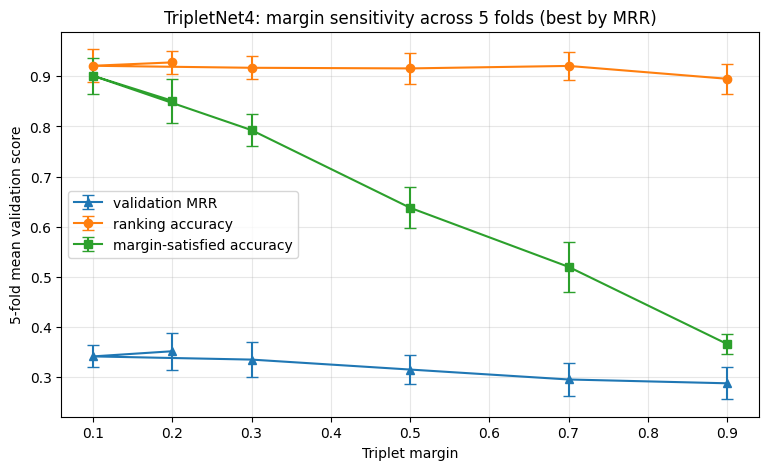

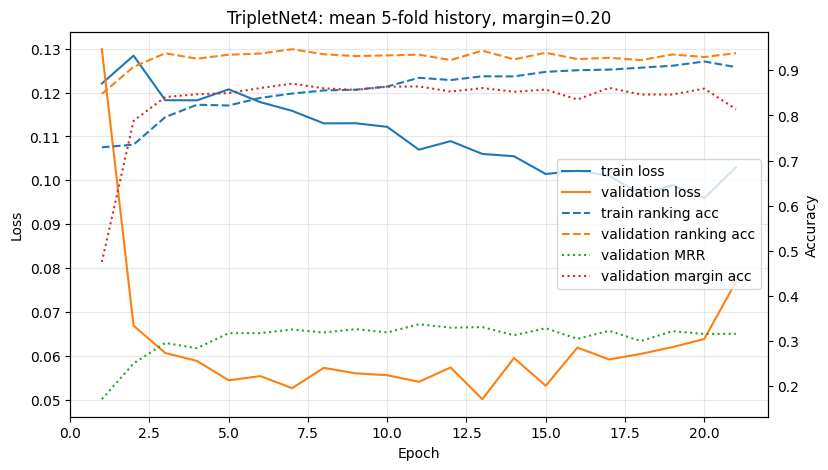

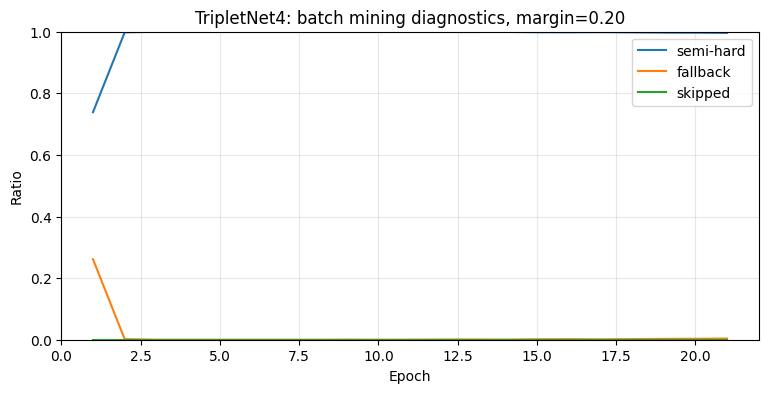

,epoch,train_loss,val_loss,val_mrr,train_acc,val_acc,val_margin_acc,semi_hard_ratio,fallback_ratio,skipped_ratio,mean_pos_dist,mean_neg_dist
16,17,0.101041,0.059178,0.322716,0.901542,0.927822,0.861093,0.998677,0.001323,0.0,0.291096,0.402689
17,18,0.096783,0.060435,0.300037,0.905835,0.922548,0.846558,0.997993,0.002007,0.0,0.288832,0.407153
18,19,0.098877,0.061987,0.321864,0.910188,0.935210,0.846362,0.997230,0.002770,0.0,0.284277,0.397270
19,20,0.095949,0.063834,0.315733,0.919550,0.929466,0.859431,0.996950,0.003050,0.0,0.281284,0.398717
20,21,0.103001,0.076868,0.316010,0.907145,0.937984,0.813953,0.996266,0.003734,0.0,0.288761,0.395251


,model,negative_mining,margin,mean_best_val_mrr,std_best_val_mrr,mean_best_val_acc,std_best_val_acc,mean_best_val_loss,mean_best_val_margin_acc,mean_semi_hard_ratio,mean_fallback_ratio,mean_skipped_ratio
0,TripletNet2,memory_bank_semihard,0.1,0.366150,0.042546,0.952668,0.007789,0.025854,0.913572,0.928523,0.071477,0.0
1,TripletNet1,memory_bank_semihard,0.1,0.355918,0.033586,0.924368,0.013661,0.036626,0.866061,0.792082,0.207918,0.0
2,TripletNet4,memory_bank_semihard,0.2,0.351774,0.036946,0.927626,0.023068,0.057849,0.851084,0.985636,0.014364,0.0
3,TripletNet3,memory_bank_semihard,0.2,0.349837,0.030909,0.933471,0.034190,0.048065,0.863720,0.978998,0.021002,0.0


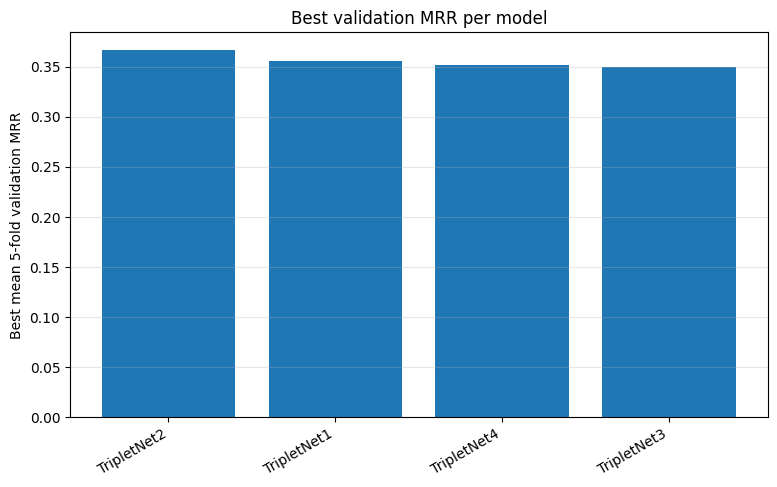

In [7]:
# 1) Cross-validation stability: margin ranking, training curves, and mining diagnostics.
cv_display = margin_summary_df.copy()
for col in [
    "mean_best_val_mrr",
    "std_best_val_mrr",
    "mean_best_val_acc",
    "std_best_val_acc",
    "mean_best_val_margin_acc",
    "std_best_val_margin_acc",
    "mean_semi_hard_ratio",
    "mean_fallback_ratio",
    "mean_skipped_ratio",
]:
    if col in cv_display.columns:
        cv_display[col] = cv_display[col].astype(float)

display(cv_display)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    cv_display["margin"].astype(float),
    cv_display["mean_best_val_mrr"].astype(float),
    yerr=cv_display["std_best_val_mrr"].fillna(0).astype(float),
    marker="^",
    capsize=4,
    label="validation MRR",
)
ax.errorbar(
    cv_display["margin"].astype(float),
    cv_display["mean_best_val_acc"].astype(float),
    yerr=cv_display["std_best_val_acc"].fillna(0).astype(float),
    marker="o",
    capsize=4,
    label="ranking accuracy",
)
ax.errorbar(
    cv_display["margin"].astype(float),
    cv_display["mean_best_val_margin_acc"].astype(float),
    yerr=cv_display["std_best_val_margin_acc"].fillna(0).astype(float),
    marker="s",
    capsize=4,
    label="margin-satisfied accuracy",
)
ax.set_xlabel("Triplet margin")
ax.set_ylabel("5-fold mean validation score")
ax.set_title(f"{MODEL_NAME}: margin sensitivity across 5 folds (best by MRR)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


def plot_cv_history_for_margin(results: list[dict], margin: float):
    histories = [item["history"] for item in results if float(item["margin"]) == float(margin)]
    if not histories:
        raise ValueError(f"No histories found for margin={margin}")
    combined = pd.concat(histories, ignore_index=True)
    agg_spec = {
        "train_loss": ("train_loss", "mean"),
        "val_loss": ("val_loss", "mean"),
        "val_mrr": ("val_mrr", "mean"),
        "train_acc": ("train_acc", "mean"),
        "val_acc": ("val_acc", "mean"),
        "val_margin_acc": ("val_margin_acc", "mean"),
    }
    for metric in ["semi_hard_ratio", "fallback_ratio", "skipped_ratio", "mean_pos_dist", "mean_neg_dist"]:
        if metric in combined.columns:
            agg_spec[metric] = (metric, "mean")
    cv_history = combined.groupby("epoch", as_index=False).agg(**agg_spec)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(cv_history["epoch"], cv_history["train_loss"], label="train loss")
    ax1.plot(cv_history["epoch"], cv_history["val_loss"], label="validation loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(cv_history["epoch"], cv_history["train_acc"], linestyle="--", label="train ranking acc")
    ax2.plot(cv_history["epoch"], cv_history["val_acc"], linestyle="--", label="validation ranking acc")
    ax2.plot(cv_history["epoch"], cv_history["val_mrr"], linestyle=":", label="validation MRR")
    ax2.plot(cv_history["epoch"], cv_history["val_margin_acc"], linestyle=":", label="validation margin acc")
    ax2.set_ylabel("Accuracy")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="center right")
    ax1.set_title(f"{MODEL_NAME}: mean 5-fold history, margin={margin:.2f}")
    plt.show()

    mining_cols = ["semi_hard_ratio", "fallback_ratio", "skipped_ratio"]
    if all(col in cv_history.columns for col in mining_cols):
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(cv_history["epoch"], cv_history["semi_hard_ratio"], label="semi-hard")
        ax.plot(cv_history["epoch"], cv_history["fallback_ratio"], label="fallback")
        ax.plot(cv_history["epoch"], cv_history["skipped_ratio"], label="skipped")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Ratio")
        ax.set_ylim(0, 1)
        ax.set_title(f"{MODEL_NAME}: batch mining diagnostics, margin={margin:.2f}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

    return cv_history

cv_history_df = plot_cv_history_for_margin(results, best_margin)
display(cv_history_df.tail())

# Optional cross-notebook comparison. This becomes useful after running model1.ipynb ... model5.ipynb.
def load_available_model_summaries(root: Path = Path("checkpoints")) -> pd.DataFrame:
    frames = []
    for path in sorted(root.glob("TripletNet*/TripletNet*_5fold_margin_summary.csv")):
        try:
            df = pd.read_csv(path)
            df["summary_path"] = str(path)
            frames.append(df)
        except Exception as exc:
            print(f"Skipping {path}: {exc}")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

all_model_summaries = load_available_model_summaries()
if not all_model_summaries.empty and "mean_best_val_mrr" not in all_model_summaries.columns:
    print("Existing summaries do not contain validation MRR yet. Re-run all model notebooks after this update.")
    all_model_summaries = pd.DataFrame()
if all_model_summaries.empty:
    print("No cross-model summaries found yet. Run the other model notebooks to enable model-level comparison.")
else:
    best_per_model = (
        all_model_summaries.sort_values(["model", "mean_best_val_mrr", "mean_best_val_acc", "mean_best_val_loss"], ascending=[True, False, False, True])
        .groupby("model", as_index=False)
        .head(1)
        .sort_values("mean_best_val_mrr", ascending=False)
        .reset_index(drop=True)
    )
    display_cols = [
        col for col in [
            "model",
            "negative_mining",
            "margin",
            "mean_best_val_mrr",
            "std_best_val_mrr",
            "mean_best_val_acc",
            "std_best_val_acc",
            "mean_best_val_loss",
            "mean_best_val_margin_acc",
            "mean_semi_hard_ratio",
            "mean_fallback_ratio",
            "mean_skipped_ratio",
        ]
        if col in best_per_model.columns
    ]
    display(best_per_model[display_cols])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(best_per_model["model"], best_per_model["mean_best_val_mrr"])
    ax.set_ylabel("Best mean 5-fold validation MRR")
    ax.set_title("Best validation MRR per model")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.show()


### 2. Out-of-fold triplet quality and threshold analysis


,model,best_margin,selection_metric,best_fold,best_fold_val_mrr,best_fold_val_acc,oof_triplets,ranking_accuracy,margin_satisfied_accuracy,mean_positive_similarity,...,mean_similarity_gap,mean_positive_distance,mean_negative_distance,mean_margin_gap,roc_auc,average_precision,best_f1_threshold,best_threshold_precision,best_threshold_recall,best_threshold_f1
0,TripletNet4,0.2,validation_mrr,1,0.389898,0.946565,658,0.927052,0.849544,0.653268,...,0.64581,0.346732,0.992542,0.64581,0.930281,0.932701,0.3488,0.845376,0.889058,0.866667


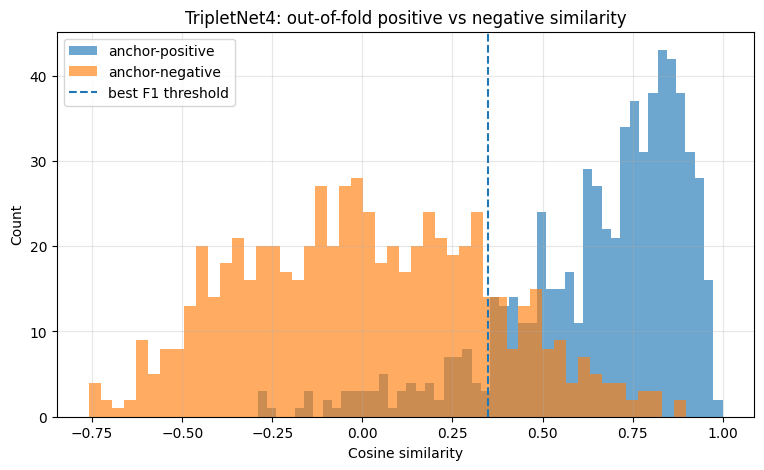

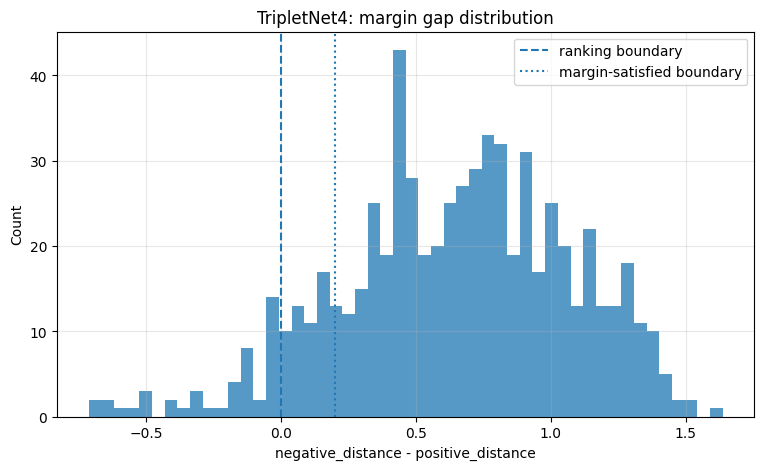

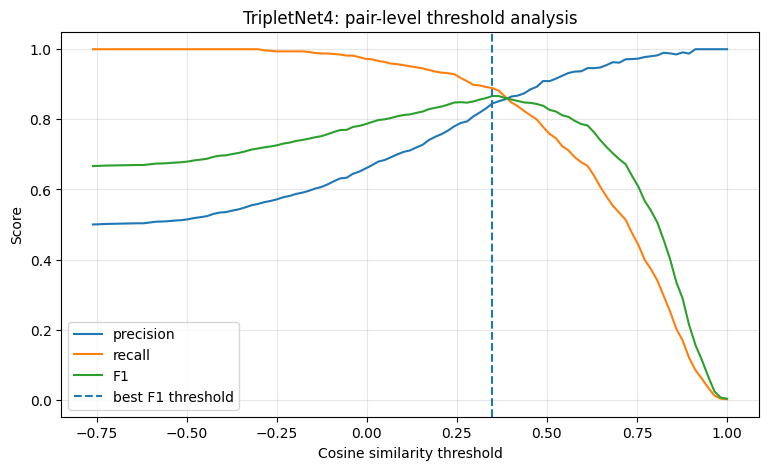

,fold,triplet_id,positive_similarity,negative_similarity,similarity_gap,positive_distance,negative_distance,margin_gap,ranking_correct,margin_satisfied
0,4,70,-0.157114,0.555570,-0.712684,1.157114,0.444430,-0.712684,False,False
1,4,71,-0.157114,0.554167,-0.711281,1.157114,0.445833,-0.711281,False,False
2,3,130,-0.057067,0.571873,-0.628940,1.057067,0.428127,-0.628940,False,False
3,5,79,-0.290746,0.333904,-0.624650,1.290746,0.666096,-0.624650,False,False
4,3,32,0.286848,0.897108,-0.610260,0.713152,0.102892,-0.610260,False,False
5,2,86,-0.106268,0.449620,-0.555889,1.106268,0.550380,-0.555889,False,False
6,4,53,-0.255107,0.247206,-0.502313,1.255107,0.752794,-0.502313,False,False
7,2,52,0.268304,0.765655,-0.497351,0.731696,0.234345,-0.497351,False,False
8,3,65,0.374071,0.870616,-0.496545,0.625929,0.129384,-0.496545,False,False
9,4,51,0.055468,0.481987,-0.426519,0.944532,0.518013,-0.426519,False,False


In [8]:

# 2) Triplet-level out-of-fold analysis: distances, gaps, threshold precision/recall.
triplet_summary = pd.DataFrame([{
    "model": MODEL_NAME,
    "best_margin": best_margin,
    "selection_metric": "validation_mrr",
    "best_fold": best_fold_result["fold"],
    "best_fold_val_mrr": best_fold_result["best_val_mrr"],
    "best_fold_val_acc": best_fold_result["best_val_acc"],
    "oof_triplets": len(oof_triplet_df),
    "ranking_accuracy": oof_triplet_df["ranking_correct"].mean(),
    "margin_satisfied_accuracy": oof_triplet_df["margin_satisfied"].mean(),
    "mean_positive_similarity": oof_triplet_df["positive_similarity"].mean(),
    "mean_negative_similarity": oof_triplet_df["negative_similarity"].mean(),
    "mean_similarity_gap": oof_triplet_df["similarity_gap"].mean(),
    "mean_positive_distance": oof_triplet_df["positive_distance"].mean(),
    "mean_negative_distance": oof_triplet_df["negative_distance"].mean(),
    "mean_margin_gap": oof_triplet_df["margin_gap"].mean(),
    "roc_auc": auc_metrics["roc_auc"],
    "average_precision": auc_metrics["average_precision"],
    "best_f1_threshold": best_threshold_row["threshold"],
    "best_threshold_precision": best_threshold_row["precision"],
    "best_threshold_recall": best_threshold_row["recall"],
    "best_threshold_f1": best_threshold_row["f1"],
}])
display(triplet_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(oof_triplet_df["positive_similarity"], bins=50, alpha=0.65, label="anchor-positive")
ax.hist(oof_triplet_df["negative_similarity"], bins=50, alpha=0.65, label="anchor-negative")
ax.axvline(float(best_threshold_row["threshold"]), linestyle="--", label="best F1 threshold")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Count")
ax.set_title(f"{MODEL_NAME}: out-of-fold positive vs negative similarity")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(oof_triplet_df["margin_gap"], bins=50, alpha=0.75)
ax.axvline(0.0, linestyle="--", label="ranking boundary")
ax.axvline(best_margin, linestyle=":", label="margin-satisfied boundary")
ax.set_xlabel("negative_distance - positive_distance")
ax.set_ylabel("Count")
ax.set_title(f"{MODEL_NAME}: margin gap distribution")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_metrics_df["threshold"], threshold_metrics_df["precision"], label="precision")
ax.plot(threshold_metrics_df["threshold"], threshold_metrics_df["recall"], label="recall")
ax.plot(threshold_metrics_df["threshold"], threshold_metrics_df["f1"], label="F1")
ax.axvline(float(best_threshold_row["threshold"]), linestyle="--", label="best F1 threshold")
ax.set_xlabel("Cosine similarity threshold")
ax.set_ylabel("Score")
ax.set_title(f"{MODEL_NAME}: pair-level threshold analysis")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

hardest_triplets = oof_triplet_df.sort_values("similarity_gap").head(20).reset_index(drop=True)
display(hardest_triplets[[
    "fold", "triplet_id", "positive_similarity", "negative_similarity", "similarity_gap",
    "positive_distance", "negative_distance", "margin_gap", "ranking_correct", "margin_satisfied"
]])


### 3. Retrieval metrics and qualitative nearest neighbours


In [9]:

# 3) Retrieval analysis: nearest-neighbour quality in the learned artist latent space.
@torch.inference_mode()
def encode_artists(model, artist_tensors: dict[str, torch.Tensor], batch_size: int = 256) -> pd.DataFrame:
    model.eval()
    artist_ids = sorted(map(str, artist_tensors.keys()))
    embedding_chunks = []
    for start in range(0, len(artist_ids), batch_size):
        batch_ids = artist_ids[start:start + batch_size]
        batch = torch.stack([artist_tensors[artist_id].float() for artist_id in batch_ids], dim=0).to(DEVICE)
        encoded = model.forward_once(batch).detach().cpu().float()
        encoded = F.normalize(encoded, dim=1, eps=1e-8)
        embedding_chunks.append(encoded.numpy())
    matrix = np.vstack(embedding_chunks)
    columns = [f"z_{i:03d}" for i in range(matrix.shape[1])]
    return pd.DataFrame(matrix, index=artist_ids, columns=columns)


def build_ground_truth_positive_sets(df: pd.DataFrame, available_ids: set[str], symmetric: bool = True) -> dict[str, set[str]]:
    positives = defaultdict(set)
    clean = df.copy()
    for col in TRIPLET_COLUMNS:
        clean[col] = clean[col].astype(str)
    for row in clean.itertuples(index=False):
        anchor = str(getattr(row, "anchor"))
        positive = str(getattr(row, "positive"))
        if anchor in available_ids and positive in available_ids and anchor != positive:
            positives[anchor].add(positive)
            if symmetric:
                positives[positive].add(anchor)
    return dict(positives)


def compute_retrieval_metrics(embedding_df: pd.DataFrame, positive_sets: dict[str, set[str]], ks=(1, 5, 10, 20)):
    artist_ids = embedding_df.index.astype(str).tolist()
    id_to_idx = {artist_id: idx for idx, artist_id in enumerate(artist_ids)}
    matrix = embedding_df.to_numpy(dtype=np.float32)
    matrix = matrix / np.maximum(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8)
    similarity = matrix @ matrix.T
    np.fill_diagonal(similarity, -np.inf)

    rows = []
    nearest_rows = []
    for anchor_id, positives in positive_sets.items():
        if anchor_id not in id_to_idx:
            continue
        positives = {p for p in positives if p in id_to_idx and p != anchor_id}
        if not positives:
            continue
        anchor_idx = id_to_idx[anchor_id]
        order = np.argsort(-similarity[anchor_idx])
        ranked_ids = [artist_ids[i] for i in order]
        ranked_positive_flags = np.array([candidate in positives for candidate in ranked_ids], dtype=bool)

        row = {
            "anchor": anchor_id,
            "num_positives": len(positives),
        }
        for k in ks:
            topk_flags = ranked_positive_flags[:k]
            hits = int(topk_flags.sum())
            row[f"precision@{k}"] = hits / k
            row[f"recall@{k}"] = hits / len(positives)
            row[f"hit@{k}"] = float(hits > 0)

        positive_ranks = np.flatnonzero(ranked_positive_flags) + 1
        row["mrr"] = 1.0 / positive_ranks[0] if len(positive_ranks) else 0.0
        if len(positive_ranks):
            precisions_at_hits = []
            for rank in positive_ranks:
                precisions_at_hits.append(ranked_positive_flags[:rank].sum() / rank)
            row["average_precision"] = float(np.sum(precisions_at_hits) / len(positives))
        else:
            row["average_precision"] = 0.0
        rows.append(row)

        for rank, candidate_idx in enumerate(order[:10], start=1):
            candidate_id = artist_ids[candidate_idx]
            nearest_rows.append({
                "anchor": anchor_id,
                "rank": rank,
                "candidate": candidate_id,
                "cosine_similarity": float(similarity[anchor_idx, candidate_idx]),
                "is_ground_truth_positive": candidate_id in positives,
            })

    metric_df = pd.DataFrame(rows)
    nearest_df = pd.DataFrame(nearest_rows)
    if metric_df.empty:
        summary = pd.DataFrame()
    else:
        summary = metric_df.drop(columns=["anchor"]).mean(numeric_only=True).to_frame("mean").T
        summary.insert(0, "model", MODEL_NAME)
        summary.insert(1, "checkpoint", str(best_checkpoint_path))
    return metric_df, summary, nearest_df

artist_embedding_df = encode_artists(best_model, artist_averages)
positive_sets = build_ground_truth_positive_sets(filtered_triplet_df, set(artist_embedding_df.index), symmetric=True)
retrieval_metric_df, retrieval_summary_df, nearest_neighbors_df = compute_retrieval_metrics(
    artist_embedding_df,
    positive_sets,
    ks=(1, 5, 10, 20),
)

print(f"Encoded artists: {len(artist_embedding_df)}")
print(f"Artists with at least one ground-truth positive: {len(positive_sets)}")
display(retrieval_summary_df)
display(retrieval_metric_df.sort_values("average_precision", ascending=False).head(10))
display(retrieval_metric_df.sort_values("average_precision", ascending=True).head(10))
display(nearest_neighbors_df.head(50))


Encoded artists: 3892
Artists with at least one ground-truth positive: 2645


,model,checkpoint,num_positives,precision@1,recall@1,hit@1,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,mrr,average_precision
mean,TripletNet4,checkpoints/TripletNet4/TripletNet4_margin_0.2...,5.9569,0.33535,0.062824,0.33535,0.266919,0.22687,0.620038,0.216635,0.346585,0.722495,0.158166,0.490403,0.796975,0.463501,0.282187


,anchor,num_positives,precision@1,recall@1,hit@1,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,mrr,average_precision
2183,79001b57-792f-42d8-a580-cfd1f709cd6d,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
603,d1da3f8d-3b16-468f-a1b2-9a8d9b138bc6,6,1.0,0.166667,1.0,1.0,0.833333,1.0,0.6,1.0,1.0,0.30,1.0,1.0,1.0,1.0
745,8cfaf3df-e098-4722-b840-dbc84d7aee20,7,1.0,0.142857,1.0,1.0,0.714286,1.0,0.7,1.0,1.0,0.35,1.0,1.0,1.0,1.0
2587,15307eba-0a4d-4e0f-89f1-3b55f6726a7e,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
1807,b4eed615-abb4-4ba8-bb74-ba649a881f6a,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
1764,f3bb45c8-dcb3-4358-ab21-645e6d0935e4,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
1768,babb741d-c3ce-4a89-84f4-55d1042251d2,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
1769,5347379f-c2e6-4793-9b6b-1a4a0315cf2e,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
763,7a1eb805-2242-4daa-bd90-c1ed350e2e48,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0
1196,929ca8c3-5df3-4fe9-bc59-f8d603780bce,1,1.0,1.000000,1.0,0.2,1.000000,1.0,0.1,1.0,1.0,0.05,1.0,1.0,1.0,1.0


,anchor,num_positives,precision@1,recall@1,hit@1,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,mrr,average_precision
1682,61a8c3e7-2853-49eb-ba59-1bc7eee2750f,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000326,0.000326
2041,b4265534-cf8f-4a8f-827d-fc490ccd15b8,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000332,0.000332
908,97672881-2f1c-4aed-9cb7-a510ae9792dd,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000342,0.000342
2073,caae4789-c38c-4803-8808-2886b37ca8f9,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000615,0.000615
1926,fc31ddde-0030-4cc3-9180-5cc4e7004fef,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000690,0.000690
1828,4d873915-b3f4-4b42-99f3-4640bc106b1b,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000819,0.000819
2105,68d3a2a5-d1da-418f-a9bb-3fc9ef9b27a8,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000863,0.000863
1400,35019ce9-92af-4c69-b3d1-a5f29720b23e,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000921,0.000921
2108,8a562b21-af9e-4b6a-8c43-327cdf6713b0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000934,0.000934
1082,36dc09e7-93da-4c23-bc0d-dcb68c8ed74f,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000970,0.000970


,anchor,rank,candidate,cosine_similarity,is_ground_truth_positive
0,acb5a55d-2e39-4098-962e-acbc68adc663,1,e491fae8-3a5a-438e-8368-925753fb41a1,0.930712,False
1,acb5a55d-2e39-4098-962e-acbc68adc663,2,1144f22d-fb1f-41a7-9822-05dab5edff25,0.919968,False
2,acb5a55d-2e39-4098-962e-acbc68adc663,3,8b03861e-468d-4694-a7c3-4d1cf5dfe2d2,0.919819,False
3,acb5a55d-2e39-4098-962e-acbc68adc663,4,87684162-ab42-4cfa-bf22-ebe237035f54,0.905475,True
4,acb5a55d-2e39-4098-962e-acbc68adc663,5,3cc3942d-bbfc-446d-a8f4-f0e1e238ca86,0.897705,False
5,acb5a55d-2e39-4098-962e-acbc68adc663,6,9aa0d535-3efe-468c-afda-43bd17d44641,0.888911,False
6,acb5a55d-2e39-4098-962e-acbc68adc663,7,8a0e10a9-80c7-40e0-bf5b-89f1d57f9537,0.879701,False
7,acb5a55d-2e39-4098-962e-acbc68adc663,8,5c6acb91-4b9b-4245-b92f-e817295c4ed0,0.878436,False
8,acb5a55d-2e39-4098-962e-acbc68adc663,9,614b892d-4f1a-4d1a-b382-dcc17ee159bc,0.868089,False
9,acb5a55d-2e39-4098-962e-acbc68adc663,10,e0827234-3be3-4973-be59-1aa9575b9c76,0.863186,False


### 4. Latent-space visualisation and metadata consistency


In [10]:

# 4) Metadata-aware latent-space analysis: t-SNE/PCA and group similarity.
def load_artist_metadata() -> pd.DataFrame:
    candidate_paths = [
        Path("artists_genre_country.csv"),
        Path("artists_genre_country_major_genres.csv"),
        Path("artists.csv"),
        Path("artists_metadata.csv"),
        Path("metadata.csv"),
    ]
    for path in candidate_paths:
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df.columns = [str(col).strip() for col in df.columns]
        lower_map = {col.lower(): col for col in df.columns}
        id_col = None
        for candidate in ["musicbrainz_id", "artist_id", "id", "mbid"]:
            if candidate in lower_map:
                id_col = lower_map[candidate]
                break
        if id_col is None:
            print(f"Skipping metadata file without artist id column: {path}")
            continue
        df = df.rename(columns={id_col: "artist_id"})
        df["artist_id"] = df["artist_id"].astype(str)
        df["metadata_source"] = str(path)
        return df
    return pd.DataFrame()


def infer_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    lower_map = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None

artist_metadata_df = load_artist_metadata()
if artist_metadata_df.empty:
    print("No metadata file found. t-SNE and intra/inter-group similarity by country/genre are skipped.")
else:
    country_col = infer_column(artist_metadata_df, ["country", "nationality", "artist_country"])
    genre_col = infer_column(artist_metadata_df, ["genre", "genres", "general_genre", "main_genre", "music_genre"])
    name_col = infer_column(artist_metadata_df, ["name", "artist", "artist_name"])

    metadata_embedding_df = artist_embedding_df.reset_index(names="artist_id").merge(artist_metadata_df, on="artist_id", how="left")
    display(metadata_embedding_df.head())

    def plot_latent_projection(label_col: str | None, method: str = "tsne", max_points: int = 2500):
        if label_col is None or label_col not in metadata_embedding_df.columns:
            print(f"No usable label column for {method.upper()} plot.")
            return None
        plot_df = metadata_embedding_df.dropna(subset=[label_col]).copy()
        if plot_df.empty:
            print(f"No non-null labels in column {label_col}.")
            return None
        if len(plot_df) > max_points:
            plot_df = plot_df.sample(max_points, random_state=SEED).copy()
        feature_cols = [col for col in plot_df.columns if col.startswith("z_")]
        x = plot_df[feature_cols].to_numpy(dtype=np.float32)

        try:
            if method == "pca":
                from sklearn.decomposition import PCA
                coords = PCA(n_components=2, random_state=SEED).fit_transform(x)
            else:
                from sklearn.manifold import TSNE
                perplexity = min(40, max(5, (len(plot_df) - 1) // 3))
                kwargs = dict(n_components=2, random_state=SEED, metric="cosine", init="pca", perplexity=perplexity)
                try:
                    coords = TSNE(max_iter=1000, **kwargs).fit_transform(x)
                except TypeError:
                    coords = TSNE(n_iter=1000, **kwargs).fit_transform(x)
        except Exception as exc:
            print(f"{method.upper()} skipped: {exc}")
            return None

        plot_df["dim_1"] = coords[:, 0]
        plot_df["dim_2"] = coords[:, 1]

        labels = plot_df[label_col].astype(str).fillna("Unknown")
        top_labels = labels.value_counts().head(12).index.tolist()
        plot_df["plot_label"] = np.where(labels.isin(top_labels), labels, "Other")

        fig, ax = plt.subplots(figsize=(10, 7))
        for label, group in plot_df.groupby("plot_label"):
            ax.scatter(group["dim_1"], group["dim_2"], s=12, alpha=0.75, label=label)
        ax.set_title(f"{MODEL_NAME}: {method.upper()} latent space by {label_col}")
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.grid(True, alpha=0.2)
        ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
        return plot_df

    pca_country_df = plot_latent_projection(country_col, method="pca")
    tsne_country_df = plot_latent_projection(country_col, method="tsne")
    if genre_col is not None and genre_col != country_col:
        pca_genre_df = plot_latent_projection(genre_col, method="pca")
        tsne_genre_df = plot_latent_projection(genre_col, method="tsne")

    def group_similarity_summary(label_col: str | None, min_group_size: int = 5, max_pairs: int = 20000) -> pd.DataFrame:
        if label_col is None or label_col not in metadata_embedding_df.columns:
            return pd.DataFrame()
        df = metadata_embedding_df.dropna(subset=[label_col]).copy()
        feature_cols = [col for col in df.columns if col.startswith("z_")]
        matrix = df[feature_cols].to_numpy(dtype=np.float32)
        matrix = matrix / np.maximum(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8)
        labels = df[label_col].astype(str).to_numpy()
        rng = np.random.default_rng(SEED)
        rows = []
        for label in sorted(pd.Series(labels).dropna().unique()):
            idx = np.flatnonzero(labels == label)
            other_idx = np.flatnonzero(labels != label)
            if len(idx) < min_group_size or len(other_idx) == 0:
                continue

            n_possible = len(idx) * (len(idx) - 1) // 2
            n_pairs = min(max_pairs, n_possible)
            if n_pairs <= 0:
                continue
            i = rng.choice(idx, size=n_pairs, replace=True)
            j = rng.choice(idx, size=n_pairs, replace=True)
            keep = i != j
            i, j = i[keep], j[keep]
            if len(i) == 0:
                continue
            intra = np.sum(matrix[i] * matrix[j], axis=1)

            inter_i = rng.choice(idx, size=len(i), replace=True)
            inter_j = rng.choice(other_idx, size=len(i), replace=True)
            inter = np.sum(matrix[inter_i] * matrix[inter_j], axis=1)

            rows.append({
                "label_column": label_col,
                "label": label,
                "n_artists": len(idx),
                "mean_intra_similarity": float(np.mean(intra)),
                "std_intra_similarity": float(np.std(intra)),
                "mean_inter_similarity": float(np.mean(inter)),
                "std_inter_similarity": float(np.std(inter)),
                "intra_minus_inter": float(np.mean(intra) - np.mean(inter)),
            })
        return pd.DataFrame(rows).sort_values("intra_minus_inter", ascending=False).reset_index(drop=True)

    country_similarity_df = group_similarity_summary(country_col)
    genre_similarity_df = group_similarity_summary(genre_col)
    if not country_similarity_df.empty:
        display(country_similarity_df)
    if not genre_similarity_df.empty:
        display(genre_similarity_df)


No metadata file found. t-SNE and intra/inter-group similarity by country/genre are skipped.


### 5. Error analysis and exported result files


In [11]:

# 5) Error analysis and artifact export.
threshold = float(best_threshold_row["threshold"])
positive_pair_df = oof_triplet_df[["fold", "triplet_id", "positive_similarity"]].rename(
    columns={"positive_similarity": "similarity"}
)
positive_pair_df["pair_label"] = 1
positive_pair_df["predicted_positive"] = positive_pair_df["similarity"] >= threshold

negative_pair_df = oof_triplet_df[["fold", "triplet_id", "negative_similarity"]].rename(
    columns={"negative_similarity": "similarity"}
)
negative_pair_df["pair_label"] = 0
negative_pair_df["predicted_positive"] = negative_pair_df["similarity"] >= threshold

pair_error_df = pd.concat([positive_pair_df, negative_pair_df], ignore_index=True)
pair_error_df["error_type"] = np.select(
    [
        (pair_error_df["pair_label"] == 1) & (~pair_error_df["predicted_positive"]),
        (pair_error_df["pair_label"] == 0) & (pair_error_df["predicted_positive"]),
    ],
    ["false_negative_positive_pair", "false_positive_negative_pair"],
    default="correct",
)

false_positive_pairs = pair_error_df[pair_error_df["error_type"] == "false_positive_negative_pair"].sort_values("similarity", ascending=False)
false_negative_pairs = pair_error_df[pair_error_df["error_type"] == "false_negative_positive_pair"].sort_values("similarity", ascending=True)

print(f"Threshold used for pair error analysis: {threshold:.3f}")
print(f"False-positive negative pairs: {len(false_positive_pairs)}")
print(f"False-negative positive pairs: {len(false_negative_pairs)}")
display(false_positive_pairs.head(20))
display(false_negative_pairs.head(20))

# Save everything needed for the thesis/results section.
oof_triplet_path = ANALYSIS_DIR / f"{MODEL_NAME}_oof_triplet_predictions.csv"
threshold_path = ANALYSIS_DIR / f"{MODEL_NAME}_threshold_metrics.csv"
triplet_summary_path = ANALYSIS_DIR / f"{MODEL_NAME}_triplet_summary.csv"
retrieval_metric_path = ANALYSIS_DIR / f"{MODEL_NAME}_retrieval_per_anchor.csv"
retrieval_summary_path = ANALYSIS_DIR / f"{MODEL_NAME}_retrieval_summary.csv"
nearest_neighbors_path = ANALYSIS_DIR / f"{MODEL_NAME}_nearest_neighbors.csv"
pair_error_path = ANALYSIS_DIR / f"{MODEL_NAME}_pair_error_analysis.csv"
artist_embedding_path = ANALYSIS_DIR / f"{MODEL_NAME}_artist_latent_embeddings.csv"

oof_triplet_df.to_csv(oof_triplet_path, index=False)
threshold_metrics_df.to_csv(threshold_path, index=False)
triplet_summary.to_csv(triplet_summary_path, index=False)
retrieval_metric_df.to_csv(retrieval_metric_path, index=False)
retrieval_summary_df.to_csv(retrieval_summary_path, index=False)
nearest_neighbors_df.to_csv(nearest_neighbors_path, index=False)
pair_error_df.to_csv(pair_error_path, index=False)
artist_embedding_df.reset_index(names="artist_id").to_csv(artist_embedding_path, index=False)

if "country_similarity_df" in globals() and isinstance(country_similarity_df, pd.DataFrame) and not country_similarity_df.empty:
    country_similarity_df.to_csv(ANALYSIS_DIR / f"{MODEL_NAME}_country_similarity_summary.csv", index=False)
if "genre_similarity_df" in globals() and isinstance(genre_similarity_df, pd.DataFrame) and not genre_similarity_df.empty:
    genre_similarity_df.to_csv(ANALYSIS_DIR / f"{MODEL_NAME}_genre_similarity_summary.csv", index=False)

print("Saved analysis artifacts to:")
for path in [
    oof_triplet_path,
    threshold_path,
    triplet_summary_path,
    retrieval_metric_path,
    retrieval_summary_path,
    nearest_neighbors_path,
    pair_error_path,
    artist_embedding_path,
]:
    print(" -", path)


Threshold used for pair error analysis: 0.349
False-positive negative pairs: 107
False-negative positive pairs: 73


,fold,triplet_id,similarity,pair_label,predicted_positive,error_type
941,3,32,0.897108,0,True,false_positive_negative_pair
974,3,65,0.870616,0,True,false_positive_negative_pair
1103,4,57,0.812448,0,True,false_positive_negative_pair
1281,5,106,0.810414,0,True,false_positive_negative_pair
736,1,78,0.803779,0,True,false_positive_negative_pair
1246,5,71,0.786878,0,True,false_positive_negative_pair
1073,4,27,0.767754,0,True,false_positive_negative_pair
841,2,52,0.765655,0,True,false_positive_negative_pair
1008,3,99,0.749074,0,True,false_positive_negative_pair
945,3,36,0.735959,0,True,false_positive_negative_pair


,fold,triplet_id,similarity,pair_label,predicted_positive,error_type
597,5,80,-0.290746,1,False,false_negative_positive_pair
596,5,79,-0.290746,1,False,false_negative_positive_pair
525,5,8,-0.284180,1,False,false_negative_positive_pair
441,4,53,-0.255107,1,False,false_negative_positive_pair
622,5,105,-0.165439,1,False,false_negative_positive_pair
458,4,70,-0.157114,1,False,false_negative_positive_pair
459,4,71,-0.157114,1,False,false_negative_positive_pair
474,4,86,-0.137784,1,False,false_negative_positive_pair
217,2,86,-0.106268,1,False,false_negative_positive_pair
624,5,107,-0.086140,1,False,false_negative_positive_pair


Saved analysis artifacts to:
 - checkpoints/TripletNet4/analysis/TripletNet4_oof_triplet_predictions.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_threshold_metrics.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_triplet_summary.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_retrieval_per_anchor.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_retrieval_summary.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_nearest_neighbors.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_pair_error_analysis.csv
 - checkpoints/TripletNet4/analysis/TripletNet4_artist_latent_embeddings.csv
